# NYC PLUTO Mini Project

This notebook contains the mini project analysis. It is organized in three parts:

- **Part A:** Principal Component Analysis
- **Part B:** t-SNE Visualization
- **Part D:** Discussion

Parts B and D are scaffolded below and will be completed in subsequent work sessions.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

RANDOM_STATE = 42
SAMPLE_SIZE  = 10_000

# Robust project-root detection, independent of any single notebook path
search_dir = Path.cwd().resolve()
for candidate in [search_dir, *search_dir.parents]:
    if (candidate / "data" / "processed").is_dir() and (candidate / "requirements.txt").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate project root (expected data/processed/ and requirements.txt).")

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR   = PROJECT_ROOT / "reports" / "figures"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

X_SCALED_PATH     = PROCESSED_DIR / "X_scaled.csv"
FEATURES_PATH     = PROCESSED_DIR / "X_scaled_features.csv"
SAMPLE_INDEX_PATH = PROCESSED_DIR / "sample_index.csv"

FIG_PREFIX = "mini_project_"

print(f"Project root            : {PROJECT_ROOT}")
print(f"Processed data directory: {PROCESSED_DIR.relative_to(PROJECT_ROOT)}")
print(f"Figure prefix           : {FIG_PREFIX}")

Project root            : /Users/ouriouahba/Desktop/NYC_PLUTO
Processed data directory: data/processed
Figure prefix           : mini_project_


## Part A: Principal Component Analysis

### Motivation

The assignment raises three questions about PCA applied to this dataset:

1. How quickly does cumulative explained variance grow as components are added?
2. How many components is a reasonable choice?
3. Is PCA useful for visualization, clustering, or compression?

Two properties of the feature space are relevant before fitting anything.

First, several pairs of features share most of their variance. For example, residential floor area and residential unit count move closely together: a building with more area dedicated to residences tends to house more units. Similar overlap exists among the commercial area sub-categories. In a Euclidean distance space, correlated dimensions are effectively counted more than once, which can distort inter-point distances.

Second, `borough` and `landuse` are excluded from `X_scaled`. These administrative labels were withheld deliberately so that any structure found in the feature space reflects building geometry and use mix, not administrative geography.

## Section 1: Data Loading

The full standardized matrix `X_scaled` is loaded from disk. The working sub-sample of `SAMPLE_SIZE` rows is reconstructed from `sample_index.csv` using the same random state as the graded notebook, ensuring that results are comparable across notebooks.

In [2]:
X_scaled     = pd.read_csv(X_SCALED_PATH)
feature_names = pd.read_csv(FEATURES_PATH).iloc[:, 0].tolist()

rng = np.random.RandomState(RANDOM_STATE)

if SAMPLE_INDEX_PATH.exists():
    shared_sample_idx = pd.read_csv(SAMPLE_INDEX_PATH).iloc[:, 0].astype(int).to_numpy()
    if shared_sample_idx.min() < 0 or shared_sample_idx.max() >= len(X_scaled):
        raise ValueError("sample_index.csv contains row positions outside X_scaled.")
    subset_size = min(SAMPLE_SIZE, len(shared_sample_idx))
    sample_idx  = shared_sample_idx[rng.choice(len(shared_sample_idx), size=subset_size, replace=False)]
    sample_source = f"{subset_size:,} rows drawn from existing shared sample_index.csv"
else:
    subset_size = min(SAMPLE_SIZE, len(X_scaled))
    sample_idx  = rng.choice(X_scaled.index.to_numpy(), size=subset_size, replace=False)
    pd.DataFrame({"row_index": sample_idx}).to_csv(SAMPLE_INDEX_PATH, index=False)
    sample_source = f"created {subset_size:,}-row sample_index.csv from X_scaled"

X_sample = X_scaled.iloc[sample_idx].copy()

print(f"X_scaled full matrix : {X_scaled.shape[0]:,} rows x {X_scaled.shape[1]} features")
print(f"Working sub-sample   : {X_sample.shape[0]:,} rows  ({sample_source})")
print(f"Number of features   : {len(feature_names)}")
print(f"Feature names        : {feature_names}")
print()
X_sample.head()

X_scaled full matrix : 682,515 rows x 16 features
Working sub-sample   : 10,000 rows  (10,000 rows drawn from existing shared sample_index.csv)
Number of features   : 16
Feature names        : ['lotarea', 'bldgarea', 'numfloors', 'lotfront', 'lotdepth', 'unitstotal', 'unitsres', 'resarea', 'comarea', 'officearea', 'retailarea', 'garagearea', 'strgearea', 'building_age', 'building_density', 'residential_ratio']



,lotarea,bldgarea,numfloors,lotfront,lotdepth,unitstotal,unitsres,resarea,comarea,officearea,retailarea,garagearea,strgearea,building_age,building_density,residential_ratio
307260,0.953701,0.001085,0.086105,-0.570180,1.698467,0.163350,-0.024466,0.354120,-0.425647,-0.194941,-0.318567,-0.120596,-0.101129,-2.328054,-0.827909,0.329387
682384,0.397686,-1.247706,-0.223780,-0.670579,1.698467,0.163350,-0.024466,0.023515,-0.425647,-0.194941,-0.318567,-0.120596,-0.101129,0.715197,-1.287588,0.329387
298347,-1.204888,-1.378412,-0.223780,0.007117,-0.540113,-1.125912,-0.552841,-0.011088,-0.425647,-0.194941,-0.318567,-0.120596,-0.101129,-1.475944,-0.414175,0.329387
201850,-1.204888,0.378191,0.086105,-0.670579,1.698467,1.078096,-0.024466,0.251211,1.847925,-0.194941,2.724609,-0.120596,-0.101129,0.380440,1.445542,-0.936491
333938,1.052740,-0.717179,-0.223780,-0.560140,-0.430148,-1.125912,-0.552841,0.163967,-0.425647,-0.194941,-0.318567,-0.120596,-0.101129,0.106547,-1.315069,0.329387


## Section 1b: Feature Correlation Structure

Before running PCA, it is useful to verify that correlated features are actually present in the data. The heatmap below shows the pairwise Pearson correlation between all features in `X_scaled`. Blocks of features with high mutual correlation are the redundancies that PCA is designed to consolidate into fewer independent components.

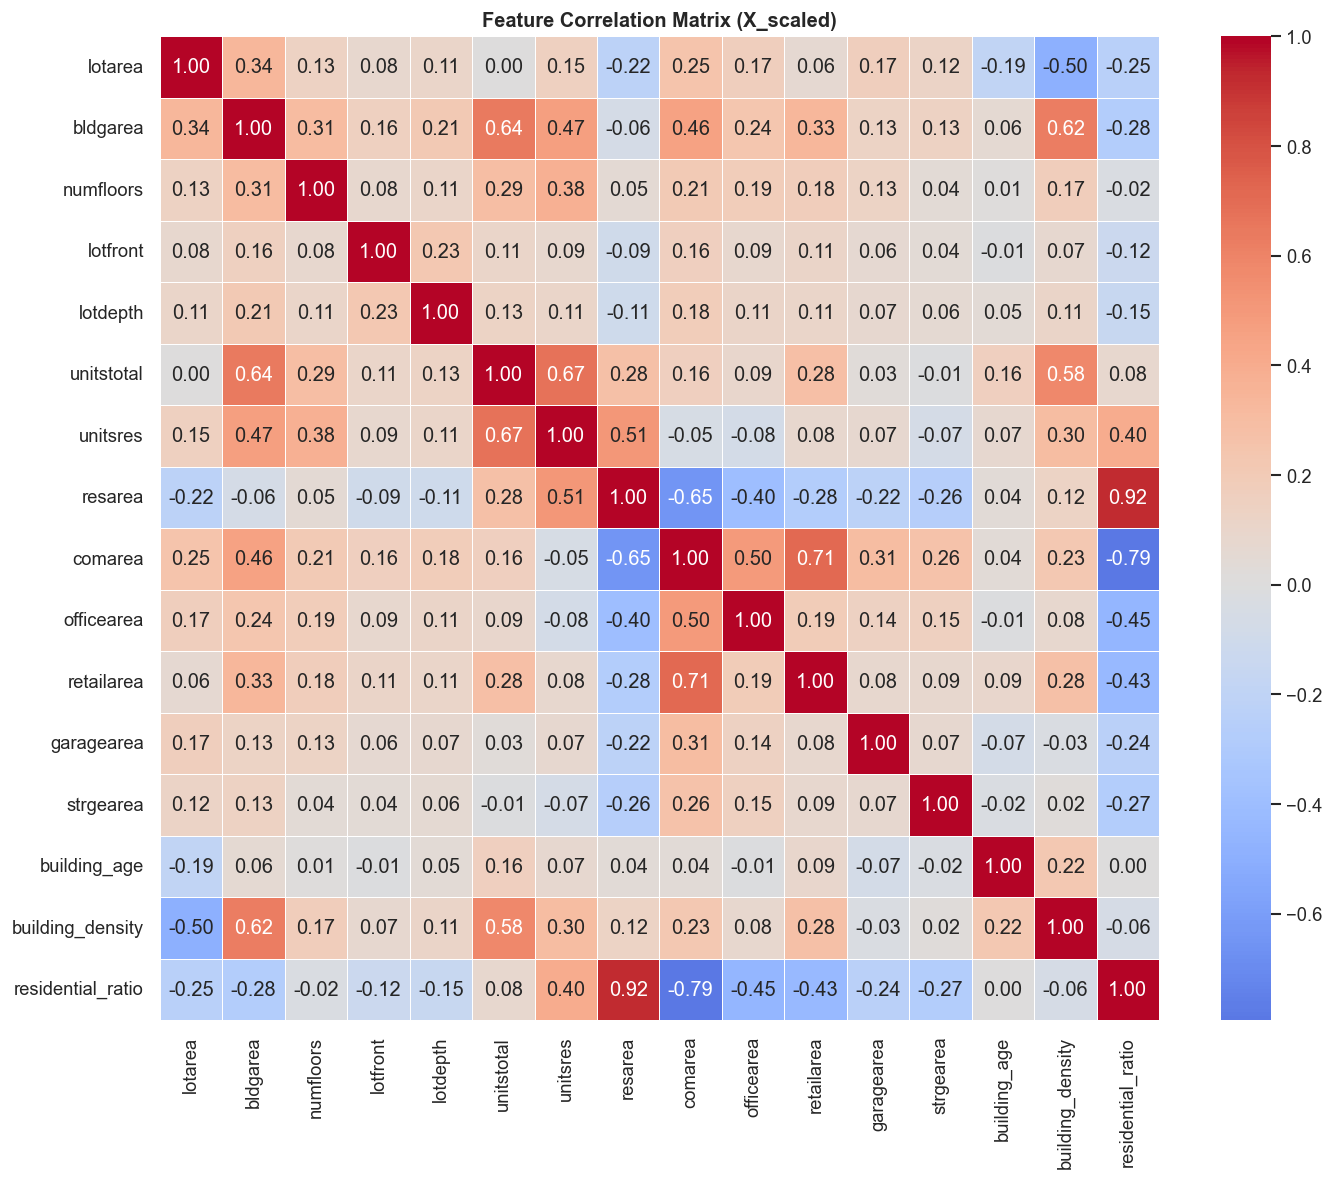

Figure saved: reports/figures/mini_project_correlation.png


In [3]:
if list(X_scaled.columns) == feature_names:
    corr_matrix = X_scaled.corr()
else:
    assert len(feature_names) == X_scaled.shape[1]  # feature_names assumed to follow X_scaled column order
    corr_matrix = pd.DataFrame(X_scaled.values, columns=feature_names).corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Feature Correlation Matrix (X_scaled)", fontweight="bold")
plt.tight_layout()
fig_path = FIGURES_DIR / f"{FIG_PREFIX}correlation.png"
plt.savefig(fig_path, bbox_inches="tight")
plt.show()
print(f"Figure saved: {fig_path.relative_to(PROJECT_ROOT)}")

## Section 2: Full-Rank PCA and Component Selection

A full-rank PCA is first fit on the complete standardized matrix to examine how explained variance distributes across all possible components. The number of components retained is then fixed at the smallest value whose cumulative explained variance reaches the 90% threshold.

In [4]:
# Full-rank PCA to find how many components reach 90% cumulative variance
pca_search = PCA(random_state=RANDOM_STATE)
pca_search.fit(X_scaled)

cumvar         = np.cumsum(pca_search.explained_variance_ratio_)
n_components_pca = int(np.searchsorted(cumvar, 0.90)) + 1

print(f"Components needed to reach 90% cumulative variance : {n_components_pca}")
print(f"Cumulative variance at {n_components_pca} components         : {cumvar[n_components_pca - 1] * 100:.2f}%")

Components needed to reach 90% cumulative variance : 10
Cumulative variance at 10 components         : 92.19%


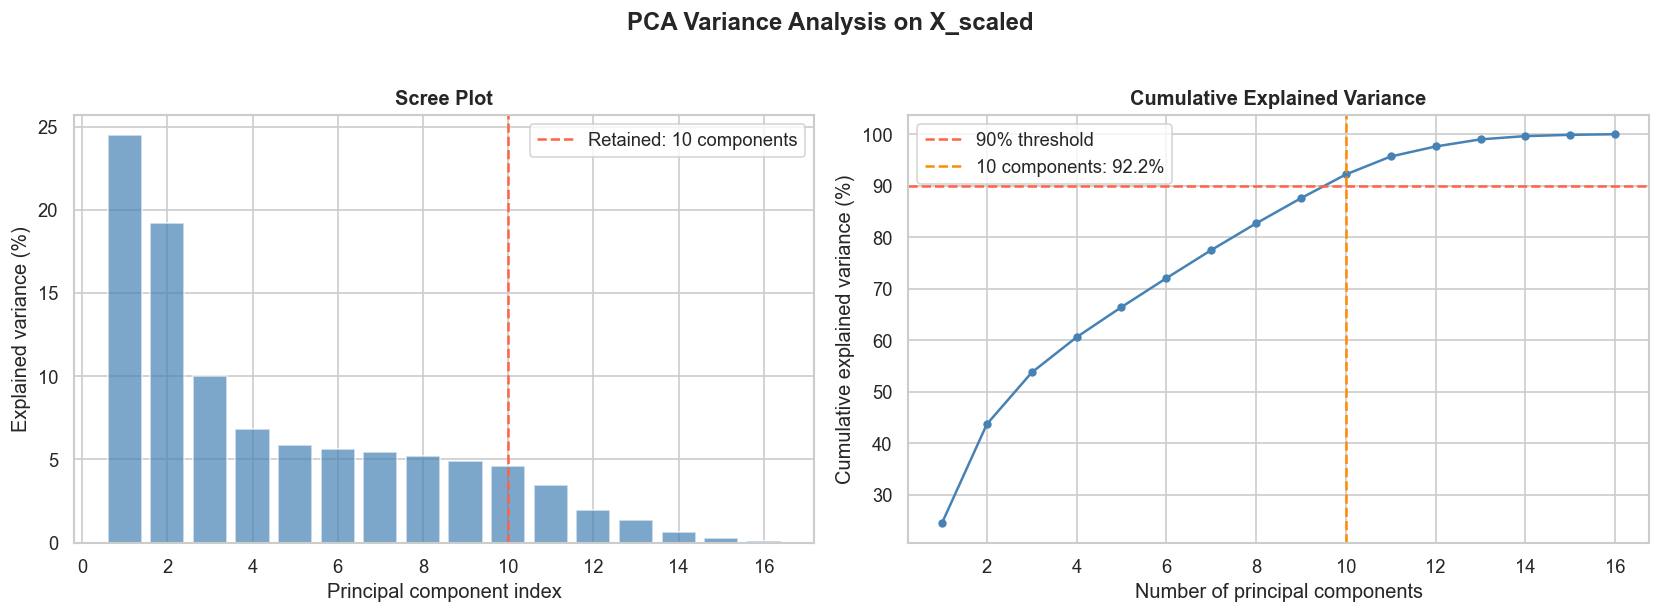

Figure saved: reports/figures/mini_project_variance.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scree plot (per-component explained variance)
ax = axes[0]
ax.bar(
    range(1, len(pca_search.explained_variance_ratio_) + 1),
    pca_search.explained_variance_ratio_ * 100,
    color="steelblue", alpha=0.7
)
ax.axvline(n_components_pca, color="tomato", linestyle="--",
           label=f"Retained: {n_components_pca} components")
ax.set_xlabel("Principal component index")
ax.set_ylabel("Explained variance (%)")
ax.set_title("Scree Plot", fontweight="bold")
ax.legend()

# Right: cumulative variance curve with 90% threshold
ax = axes[1]
ax.plot(range(1, len(cumvar) + 1), cumvar * 100, marker="o", markersize=4, color="steelblue")
ax.axhline(90, color="tomato", linestyle="--", label="90% threshold")
ax.axvline(n_components_pca, color="darkorange", linestyle="--",
           label=f"{n_components_pca} components: {cumvar[n_components_pca - 1] * 100:.1f}%")
ax.set_xlabel("Number of principal components")
ax.set_ylabel("Cumulative explained variance (%)")
ax.set_title("Cumulative Explained Variance", fontweight="bold")
ax.legend()

plt.suptitle("PCA Variance Analysis on X_scaled", fontweight="bold", y=1.02)
plt.tight_layout()
fig_path = FIGURES_DIR / f"{FIG_PREFIX}variance.png"
plt.savefig(fig_path, bbox_inches="tight")
plt.show()
print(f"Figure saved: {fig_path.relative_to(PROJECT_ROOT)}")

### Interpreting PCA Variance

**On how quickly cumulative variance grows.** The cumulative curve rises steeply at first, as the leading components capture the large correlated blocks of variance noted above, then flattens into a long tail. Reaching the 90% threshold requires retaining a substantial share of the total number of components, not just the first few. This indicates that the dataset is only moderately compressible: after the dominant correlations are absorbed, the remaining variance is distributed across many independent directions that cannot be dropped without information loss.

**On a reasonable component count.** The code above prints the exact count imposed by the 90% rule. That value is the working answer to this question: it is the smallest integer that meets the threshold, and it is determined by the data rather than chosen by hand.

**On the usefulness of PCA for different tasks.** The answer varies by task.

For *visualization*, projecting onto the first two or three components provides a readable linear summary, but it captures only a fraction of the total variance. Structure visible in a 2D or 3D PCA plot is real, but structure invisible in that projection may also exist.

For *compression*, the retained component space reduces dimensionality while keeping at least 90% of the total variance. This is a lossy compression rather than a lossless one: the discarded components still carry the remaining variance, so reconstructing the original features from the reduced representation produces an approximation, not an exact copy. The trade is worthwhile here because a high share of the variance is preserved while the dimension is reduced.

For *distance-based analysis*, removing directions that are mostly redundant can make inter-point distances more informative. Two buildings that differ only along correlated dimensions are not truly distinct in any independent sense, and collapsing those directions can sharpen the geometry. Whether this actually improves the quality of a downstream partition is an empirical question, to be evaluated at the clustering stage.

In [6]:
# Final PCA fit with the retained number of components
pca_pipeline     = PCA(n_components=n_components_pca, random_state=RANDOM_STATE)
X_pca_full_array = pca_pipeline.fit_transform(X_scaled)

X_pca = pd.DataFrame(
    X_pca_full_array,
    index=X_scaled.index,
    columns=[f"PC{i + 1}" for i in range(n_components_pca)]
)

# Align to the same sub-sample rows defined in Section 1
X_pca_sample = X_pca.iloc[sample_idx].copy()

print(f"X_pca (full matrix) shape  : {X_pca.shape}")
print(f"X_pca_sample shape         : {X_pca_sample.shape}")
print(f"X_sample shape (full-space): {X_sample.shape}")
print()
print("First rows of X_pca_sample:")
X_pca_sample.head()

X_pca (full matrix) shape  : (682515, 10)
X_pca_sample shape         : (10000, 10)
X_sample shape (full-space): (10000, 16)

First rows of X_pca_sample:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
307260,-0.457336,-0.232026,2.063813,0.495843,0.352083,0.127011,-1.098602,0.305365,-1.448852,1.486487
682384,-0.913109,-0.575545,0.575631,0.918990,-0.106738,-0.730401,1.424979,-0.028075,-0.699392,1.021778
298347,-1.608485,-1.412163,-0.291830,-0.105436,-0.220781,1.028656,-1.118270,0.581107,0.405284,0.515566
201850,2.497057,1.288477,-2.168860,0.220672,-0.647834,-0.568769,-0.447541,-0.456204,-0.336607,2.221748
333938,-1.237582,-1.485964,0.959554,-0.426490,-0.014685,-0.758328,0.524777,-0.081382,0.142294,0.025062


In [7]:
if list(X_scaled.columns) == feature_names:
    feat_labels = list(X_scaled.columns)
else:
    assert len(feature_names) == X_scaled.shape[1]  # feature_names assumed to follow X_scaled column order
    feat_labels = feature_names

loadings_df = pd.DataFrame(
    pca_pipeline.components_,
    index=[f"PC{i + 1}" for i in range(n_components_pca)],
    columns=feat_labels
)

for pc in ["PC1", "PC2"]:
    order = loadings_df.loc[pc].abs().sort_values(ascending=False).index
    signed = loadings_df.loc[pc].reindex(order)
    print(f"{pc} -- signed loadings, sorted by absolute magnitude:")
    print(signed.to_string())
    print()

PC1 -- signed loadings, sorted by absolute magnitude:
comarea              0.463763
residential_ratio   -0.408907
resarea             -0.329439
retailarea           0.328674
bldgarea             0.327860
officearea           0.291145
garagearea           0.171985
lotarea              0.167755
strgearea            0.166998
building_density     0.166937
unitstotal           0.165210
numfloors            0.160946
lotdepth             0.154241
lotfront             0.130324
unitsres             0.028341
building_age         0.025536

PC2 -- signed loadings, sorted by absolute magnitude:
unitsres             0.476200
unitstotal           0.463659
resarea              0.373741
building_density     0.365493
bldgarea             0.320546
residential_ratio    0.274922
numfloors            0.223099
building_age         0.122941
strgearea           -0.089494
lotarea             -0.086858
officearea          -0.083015
comarea             -0.077692
lotdepth             0.069180
retailarea           

### Principal Component Loadings

The first two principal components describe two largely independent axes of variation in the building stock.

**PC1 contrasts commercial use with residential use.** At one end of this axis sit the commercial area features, total commercial area, retail area, and office area, together with larger overall building area. At the opposite end sit residential ratio and residential floor area. A building at the commercial end devotes most of its space to non-residential use and tends to be physically larger, while a building at the residential end is dominated by housing. Since overall building size loads on the commercial end, PC1 is best read as a use-mix axis with a size correlate, not a pure use indicator and not a pure size indicator.

**PC2 captures residential intensity.** This axis loads strongly and in the same direction on residential unit count, total unit count, residential floor area, building density, and number of floors. The few features pulling the other way, such as lot area and the commercial categories, carry only weak loadings. The axis therefore measures how intensively a parcel is developed for housing: many residential units at high density on a given footprint, as opposed to low-density residential development. The mild negative weight on lot area reinforces this, since dense residential buildings place more units on comparatively less land.

Together, the two components separate what a building is used for, captured by PC1, from how intensively it is developed for residential use, captured by PC2.

## Part B: t-SNE

### What t-SNE Does and Does Not Do

t-SNE (t-distributed Stochastic Neighbor Embedding) is a **non-linear** dimensionality
reduction method. It places each point in 2D so that points that are close in
high-dimensional space remain close in the embedding, preserving local neighborhood
structure.

**t-SNE is a visualization tool only.** The following aspects of a t-SNE plot are
unreliable and must not be interpreted literally:

- Distances between groups (the global geometry is distorted by design)
- Cluster sizes (they reflect local density and the perplexity setting, not true volume)
- Empty space between groups (voids carry no quantitative meaning)

Only the **local neighborhood structure** is trustworthy. As a direct consequence:

- We do **not** cluster on the t-SNE embedding.
- We do **not** count or measure clusters from a t-SNE plot.

Clustering decisions are made in the original full-dimensional standardized space.
t-SNE is used exclusively to illustrate structure discovered there.

In [8]:
# Landuse labels aligned row-for-row with X_sample
# (pluto_companion.csv is row-aligned with X_scaled.csv; sample_idx holds the positions)
companion_lu = pd.read_csv(PROCESSED_DIR / "pluto_companion.csv", usecols=["landuse"])
landuse_sample = companion_lu["landuse"].iloc[sample_idx].to_numpy()

# K-Means in the full 16D standardized space (float32 for speed)
X_arr = X_sample.to_numpy(dtype=np.float32)

km2 = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
km2.fit(X_arr)
lab2 = km2.labels_

km5 = KMeans(n_clusters=5, random_state=RANDOM_STATE, n_init=10)
km5.fit(X_arr)
lab5 = km5.labels_

print("K-Means cluster sizes:")
for label, labs in [("k=2", lab2), ("k=5", lab5)]:
    sizes = dict(zip(*np.unique(labs, return_counts=True)))
    print(f"  {label}: {sizes}")

# t-SNE on X_sample (16D space -- NOT on X_pca_sample)
perplexities = [5, 30, 50]
embeddings   = {}

print("\nt-SNE KL divergences:")
for p in perplexities:
    tsne_model = TSNE(
        n_components=2,
        perplexity=p,
        init="pca",
        learning_rate="auto",
        max_iter=1000,
        random_state=RANDOM_STATE,
    )
    embeddings[p] = tsne_model.fit_transform(X_arr)
    print(f"  perplexity={p:>2d}:  KL = {tsne_model.kl_divergence_:.4f}")

K-Means cluster sizes:
  k=2: {0: 8481, 1: 1519}
  k=5: {0: 3051, 1: 5456, 2: 584, 3: 752, 4: 157}

t-SNE KL divergences:


  perplexity= 5:  KL = 1.1756


  perplexity=30:  KL = 0.8448


  perplexity=50:  KL = 0.7749


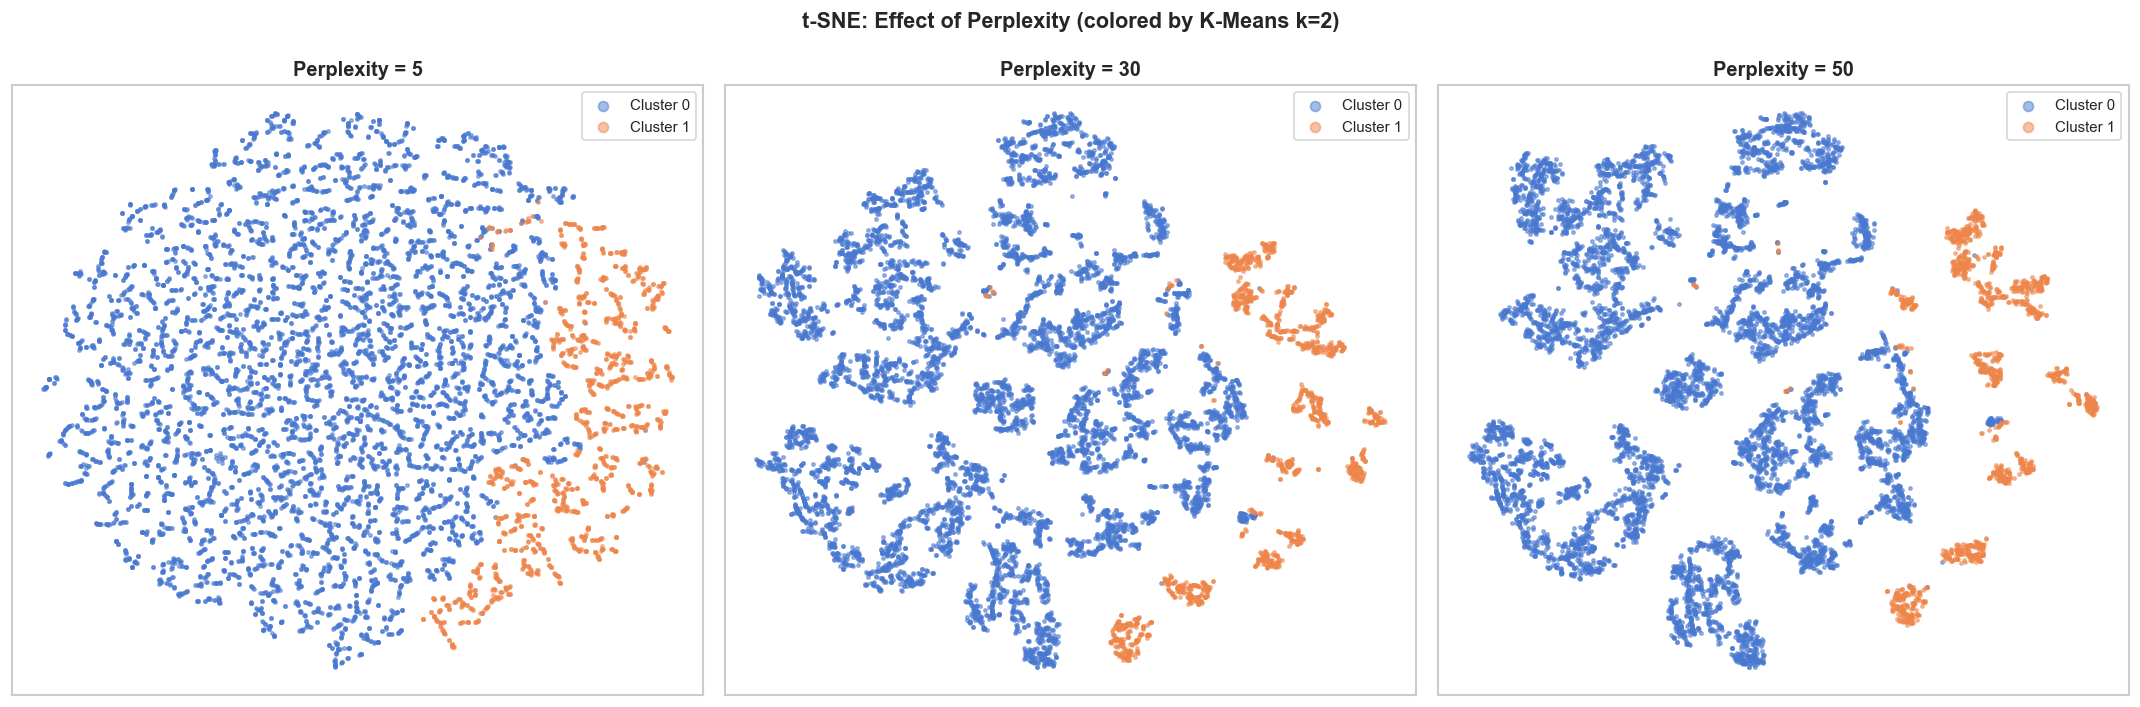

Saved: mini_project_tsne_perplexity.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, p in zip(axes, perplexities):
    for c_id in range(2):
        mask = lab2 == c_id
        ax.scatter(
            embeddings[p][mask, 0], embeddings[p][mask, 1],
            s=4, alpha=0.5, label=f"Cluster {c_id}", rasterized=True,
        )
    ax.set_title(f"Perplexity = {p}", fontweight="bold")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(markerscale=3, fontsize=9)

fig.suptitle(
    "t-SNE: Effect of Perplexity (colored by K-Means k=2)",
    fontweight="bold", fontsize=13,
)
plt.tight_layout()
fig.savefig(
    FIGURES_DIR / f"{FIG_PREFIX}tsne_perplexity.png",
    dpi=140, bbox_inches="tight",
)
plt.show()
print(f"Saved: {FIG_PREFIX}tsne_perplexity.png")

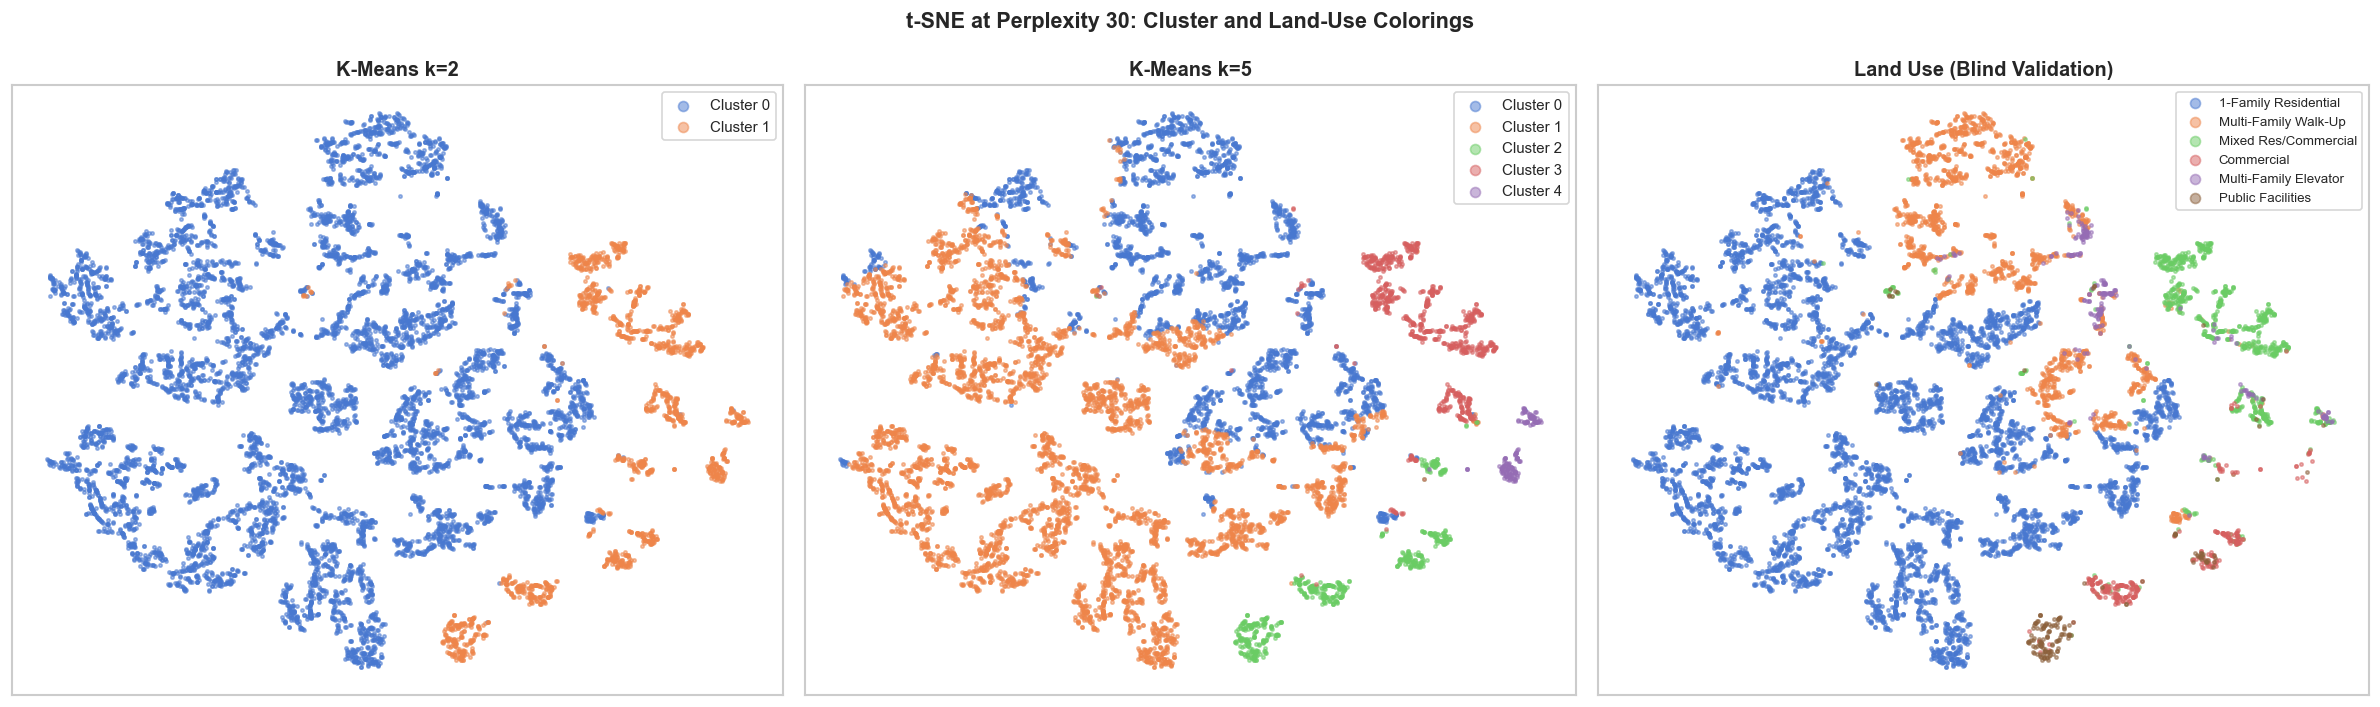

Saved: mini_project_tsne_clusters.png


In [10]:
LANDUSE_LABELS = {
    1:  "1-Family Residential",
    2:  "Multi-Family Walk-Up",
    3:  "Multi-Family Elevator",
    4:  "Mixed Res/Commercial",
    5:  "Commercial",
    6:  "Industrial",
    7:  "Transportation",
    8:  "Public Facilities",
    9:  "Open Space",
    10: "Parking",
    11: "Vacant",
}

E   = embeddings[30]
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Panel 1: K-Means k=2
for c_id in range(2):
    mask = lab2 == c_id
    axes[0].scatter(
        E[mask, 0], E[mask, 1],
        s=4, alpha=0.5, label=f"Cluster {c_id}", rasterized=True,
    )
axes[0].set_title("K-Means k=2", fontweight="bold")
axes[0].legend(markerscale=3, fontsize=9)

# Panel 2: K-Means k=5
for c_id in range(5):
    mask = lab5 == c_id
    axes[1].scatter(
        E[mask, 0], E[mask, 1],
        s=4, alpha=0.5, label=f"Cluster {c_id}", rasterized=True,
    )
axes[1].set_title("K-Means k=5", fontweight="bold")
axes[1].legend(markerscale=3, fontsize=9)

# Panel 3: land use (blind validation: landuse was never given to K-Means or t-SNE)
lu_series = pd.Series(landuse_sample).map(LANDUSE_LABELS).fillna("Other")
for cat in lu_series.value_counts().head(6).index:
    mask = (lu_series == cat).to_numpy()
    axes[2].scatter(
        E[mask, 0], E[mask, 1],
        s=4, alpha=0.5, label=cat, rasterized=True,
    )
axes[2].set_title("Land Use (Blind Validation)", fontweight="bold")
axes[2].legend(markerscale=3, fontsize=8, loc="best")

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(
    "t-SNE at Perplexity 30: Cluster and Land-Use Colorings",
    fontweight="bold", fontsize=13,
)
plt.tight_layout()
fig.savefig(
    FIGURES_DIR / f"{FIG_PREFIX}tsne_clusters.png",
    dpi=140, bbox_inches="tight",
)
plt.show()
print(f"Saved: {FIG_PREFIX}tsne_clusters.png")

### Interpretation

**Stable across perplexities.** At medium and high perplexity settings, the non-residential
cluster (the group with commercial and industrial land uses) forms its own coherent region in
the embedding. At low perplexity, the map fragments into many small local patches; this is
the expected t-SNE behavior under a small effective neighborhood, not evidence against the
residential/non-residential split. This stability indicates the residential/non-residential
split is a genuine structure in the data, not a visualization artifact produced by a
particular parameter choice.

**What changes with perplexity.** At low perplexity the layout breaks into many small,
fragmented micro-patches; at higher perplexities these consolidate into broader islands.
The apparent granularity shifts substantially between runs. This illustrates the core
warning: one must not count or size clusters from a t-SNE plot, because the number and
shape of visible blobs depend on a tuning parameter rather than on the intrinsic data
geometry.

**Blind validation by land use.** The third panel colors the same embedding by official
land-use category, a label that was never given to K-Means or to t-SNE during fitting.
Commercial and industrial types occupy clearly distinct sub-regions, while residential
types (single-family, multi-family walk-up, multi-family elevator) overlap in the large
residential mass. This independent alignment between unsupervised structure and
administrative categories confirms that the split K-Means found is real and
semantically meaningful.

**Continuum, not discrete blobs.** The overall layout shows a smooth progression of
building types rather than a handful of sharply separated blobs, consistent with the
silhouette and stability findings from the clustering notebook. There is no obvious
visual boundary that would suggest a single unambiguous number of clusters.

---

**Explicit answers to Part B questions**

**Q1: Which groups remain visible as perplexity changes?**
The residential/non-residential split is present at every perplexity setting tested.
Within the non-residential region, distinct sub-regions corresponding to commercial and
industrial land uses persist consistently across all three runs.

**Q2: What changes with perplexity?**
The local granularity changes substantially. Low perplexity produces many small,
fragmented patches; high perplexity merges them into broader, smoother regions. The
large-scale residential/non-residential separation is robust; the internal sub-structure
within each region is not stable and should not be used as evidence for a specific
cluster count.

**Q3: Does t-SNE reveal structure that was invisible before?**
It makes the continuum of building types and the separation of commercial from industrial
uses explicit in a single 2D image. It also provides independent visual confirmation that
K-Means clusters align with administrative land-use categories, without those labels
being available at any point during training. t-SNE does not, however, reveal a sharper
or unambiguous number of clusters; it illustrates and corroborates structure already
identified in the full-dimensional space.

In [11]:
# Silhouette comparison: full-dimensional space vs PCA space (k=2)
# Reuses lab2 and X_sample from Part B, X_pca_sample from Part A
km2_pca = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
km2_pca.fit(X_pca_sample)

sil_full = silhouette_score(X_sample,      lab2)
sil_pca  = silhouette_score(X_pca_sample,  km2_pca.labels_)

print("Silhouette score (k=2, Euclidean distance)")
print(f"  Full-dimensional space : {sil_full:.4f}")
print(f"  PCA space              : {sil_pca:.4f}")
print(f"  Absolute difference    : {abs(sil_full - sil_pca):.4f}")

Silhouette score (k=2, Euclidean distance)
  Full-dimensional space : 0.4676
  PCA space              : 0.4729
  Absolute difference    : 0.0054


## Part D: Discussion

### 1. Is PCA Useful for This Dataset?

PCA is useful for **decorrelating features and enabling two-dimensional visualization**:
projecting onto the first two principal components produces a readable map of the
residential/non-residential axis and the residential intensity axis.

It is weak as a **compression** technique: reaching the target variance threshold
requires the majority of the components (the exact count is printed in Part A above),
which means the dataset does not compress to a compact low-dimensional representation.
The tradeoff is acceptable because PCA does not degrade clustering: as printed above,
the silhouette score is essentially unchanged between the full-dimensional space and the
PCA space, confirming that PCA is a safe optional preprocessing step.

NMF requires a non-negative input matrix. X_scaled is standardized and therefore
contains negative values; NMF is not applicable to the representation used in this
project and is outside the scope of this mini-project.

### 2. Does t-SNE Provide Useful Visual Insight?

Yes, as a visualization. The residential/non-residential split is stable across
perplexity settings, the continuum of building types is made explicit, and land-use
categories align with the clusters in the embedding even though those categories were
never provided to K-Means or t-SNE during fitting. Together, these properties confirm
that the structure found by K-Means is real and semantically interpretable.

t-SNE remains a visualization tool only. Cluster boundaries, cluster sizes, and
inter-group distances in the embedding are not quantitatively reliable. All clustering
decisions are made in the original feature space.

### 3. Will These Methods Be Used in the Final Project?

- **PCA**: yes, for two purposes: producing readable two-dimensional projection figures,
  and as a robustness check: as printed above, clustering in PCA space and in the
  full-dimensional space yields essentially identical silhouette scores, confirming
  that the solution is not an artifact of the representation.
- **t-SNE**: yes, for one visualization figure in the final report, colored by the
  chosen K-Means cluster labels.
- **NMF**: not applicable to the standardized representation and not included in the
  final project.

### 4. Representation vs. Visualization

A **representation** is a faithful, reusable encoding of the data on which distances,
similarities, and cluster assignments can be computed reliably. PCA produces a
representation: the components capture genuine variance structure, distances in PCA
space are meaningful, and cluster assignments made there transfer back to the original
space.

A **visualization** is a two-dimensional image designed for human perception. t-SNE is
a visualization: it distorts global geometry to emphasize local neighborhoods, making it
unsuitable as a basis for computation.

The practical rule: choose k, run clustering, and evaluate metrics in a
**representation** (full-dimensional space or PCA). Use the **visualization** only to
illustrate findings; it must not drive any analytical decision.

## Annex: Theoretical Questions (Optional)

*This section answers the theoretical questions from tutorial sections 7 (t-SNE) and
8 (NMF). All mathematical notation is in plain ASCII.*

---

### Section 7: t-SNE

**7.1 What does KL(P||Q) measure?**

KL(P||Q) = sum_{ij} P_ij * log(P_ij / Q_ij)

It measures how well the two-dimensional similarities Q approximate the
high-dimensional similarities P. A value near zero means neighborhood structure is well
preserved; a larger value indicates distortion. The cost is asymmetric: it penalizes
heavily the case where P_ij is large and Q_ij is small (true neighbors placed far apart
in the map), and tolerates the case where P_ij is small and Q_ij is large
(non-neighbors placed close together).

**7.2 Why is the asymmetry of KL(P||Q) useful for t-SNE?**

Because t-SNE prioritizes preserving true local neighbors over keeping non-neighbors
apart. The term P_ij * log(P_ij / Q_ij) is large only when P_ij is large, so the
optimizer is strongly penalized for pulling genuine neighbors apart. When P_ij is small
(non-neighbors), even a large Q_ij incurs a negligible penalty. This asymmetry is why
t-SNE compresses local structure faithfully while distorting global distances.

**7.3 What does perplexity control?**

Perplexity sets the effective neighborhood size: roughly how many neighbors each point
considers when computing its conditional pairwise similarities. A low perplexity focuses
on a very local neighborhood (fragmented, granular layout); a high perplexity broadens
the neighborhood (smoother, more global layout). Results should always be compared
across several perplexity values before drawing conclusions.

**7.4 Why must clustering not be performed on a t-SNE embedding?**

t-SNE optimizes local neighborhood fidelity at the expense of global geometry.
Distances between groups, group sizes, and void regions in the embedding are artifacts
of the algorithm and the perplexity setting, not properties of the original data.
Cluster boundaries inferred from the embedding may reflect visualization parameters
rather than genuine data structure. Clustering must be performed in a representation
(original feature space or PCA); t-SNE only illustrates.

---

### Section 8: NMF

**8.1 Why are NMF components more interpretable than PCA components?**

NMF constrains both factor matrices to be non-negative: V approx W*H with W >= 0 and
H >= 0. Each observation is reconstructed as an additive combination of components
(columns of W); no subtraction is involved. PCA loadings can be negative, producing
contrast directions that mix positive and negative contributions. NMF components behave
as additive building blocks (e.g., a residential profile, a commercial profile) that
correspond directly to interpretable sub-patterns in the data.

**8.2 Is the factorization V approx W*H unique?**

No. For any positive invertible diagonal matrix D, (W*D) * (D^-1 * H) = W*H exactly.
The factorization is unique only up to a column scaling and permutation of the
components. In practice this means that the relative loadings within one component are
meaningful, but the absolute scale and the ordering of components are not determined by
the objective alone.

**8.3 Why is min ||X - W*H||_F^2 not jointly convex in (W, H)?**

The objective is convex in W with H fixed, and convex in H with W fixed. However, W*H
is bilinear in the pair (W, H): the Hessian of the joint objective is indefinite, so
the feasible region contains saddle points and multiple local minima. Standard convex
convergence guarantees do not apply; results can differ across initializations, which is
why structured initialization strategies such as NNDSVD are preferred over random
initialization.

**8.4 Gradient of ||X - W*H||_F^2 with respect to W**

Let R = W*H - X. Expanding the Frobenius norm:

  d/dW ||X - W*H||_F^2 = 2 * R * H^T = 2 * (W*H - X) * H^T

A gradient descent step on W (learning rate alpha) is:

  W_new = W - alpha * 2 * (W*H - X) * H^T

**8.5 Can a gradient step violate W >= 0? How is non-negativity enforced?**

Yes. A standard gradient step can introduce negative entries in W. Two standard
remedies are used in practice:

1. **Projected gradient**: after each step, clip negative entries to zero:
   W_new = max(W - alpha * grad_W, 0)

2. **Multiplicative update rules** (Lee and Seung): replace the additive step with a
   factor that is non-negative by construction:
   W_ik_new = W_ik * [(X * H^T)_ik / (W * H * H^T)_ik]
   These rules preserve non-negativity at every iteration and are the default solver
   strategy in most NMF implementations.